# Mikroskopisch Optische Verfahren: Programmierübung

---



## Preamble
The following code downloads and imports all necessary files and modules into the virtual machine of Colab. Please make sure to execute it before solving this exercise. This mandatory preamble will be found on all exercise sheets.

In [ ]:
import copy
import os
import random
import sys

import imageio.v3 as iio
from matplotlib import pyplot as plt
import numpy as np
import scipy


if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/OCTSoftware/MOV-Photonics.git'
    os.chdir('MOV-Photonics')


def horizontal_subplots_1x2(img1, img2, title):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
  fig.suptitle(title)
  ax1.imshow(img1, cmap='gray')
  ax2.imshow(img2, cmap='gray')
  plt.show()


def horizontal_subplots_1x3(img1, img2, img3, title):
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
  fig.suptitle(title)
  ax1.imshow(img1, cmap='gray')
  ax2.imshow(img2, cmap='gray')
  ax3.imshow(img3, cmap='gray')
  plt.show()


## Exercise 1: Introduction to Fourier Transformations
---

### a) Digital Fourier Transformation & Scaling effects

**Tasks**:
- Create a binary 129x129 px image `square` of a centered square (background set to 0, square set to 1)
- Display the absolute values of the Fourier Transformation `square_fft` and the fouriershifted Fourier Transformation `square_fftshifted` of the square.

**Programming Hints**:
- A square at position 20, 30 with halfwidth 5 would span rows 15 to 25 and columns 25 to 35. This would be indexed as such for an array called `square`: `square[15:25, 25:35]`
- Useful functions for this exercise are: [`np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html), [`np.abs`](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html), [`np.fft.fft2`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft2.html), and [`np.fft.fftshift`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftshift.html#)
- Useful syntax for this exercise is: integer division is `//`. E.g. $5 // 2 = 2$

**Questions**:
- Why do we need to use the absolute values to display data after fourier transformations?
- What is the difference between the Fourier Transformation and the shifted version? Where is the zero-frequency respectively?
- What do you observe when varying the size of the square?

**Answers**:
-

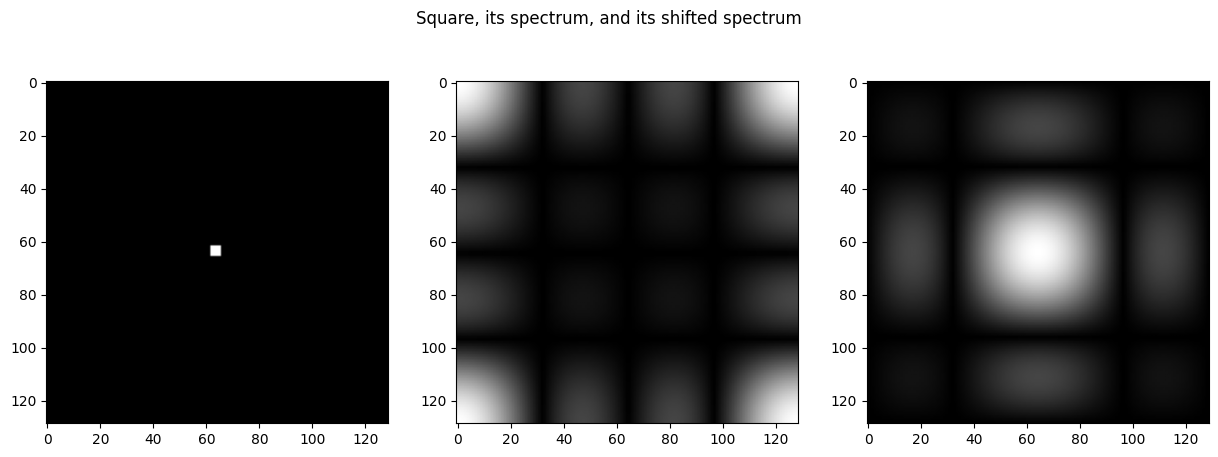

In [ ]:
# TODO: Create binary image of a centered square
square = np.zeros([129, 129])
c = 129 // 2
hw = 2
square[c-hw:c+hw, c-hw:c+hw] = 1

# TODO: Calculate absolute values of the fourier transformation of the square
square_fft = np.abs(np.fft.fft2(square))

# TODO: Calcuate fouriershifted image of square_fft
square_fftshift = np.fft.fftshift(square_fft)

horizontal_subplots_1x3(square, square_fft, square_fftshift, "Square, its spectrum, and its shifted spectrum")

### b) Further shapes, impact of size & effects of pixelation

**Tasks**:
- Implement the function `get_fft_rescaled` to return `get_fft_real` to the power of $2 * gamma$ of an input array `img`.
- Create a binary 128x128 px image `slit` of a centered vertical slit and `circle` of a centered circle.
- Get their absolute valued ffts `slit_fft_abs` of `slit` and `circle_fft_abs` of `circle` using `get_fft_real`.
- Get their scaled ffts `slit_fft` of `slit` and `circle_fft` of `circle` using `get_fft_rescaled`.

**Programming Hints**:
- Useful functions for this exercise are: `get_fft_real`, [`np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html), `get_fft_rescaled`, [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html), and [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html)
- Useful syntax for this exercise is: $x^y$ = `x ** y`
- `1 < 2 -> True`

**Questions**:
- How are fourier transformation of the slit and circle different to the one of the square?
- What do you observe for differnt sizes of the slit and circle?
- Why is the exponential weighting helpful to display spectral data?
- what do you observe when viewing the exponential spectrum of the circle and how do you explain this?

**Answers**:
-

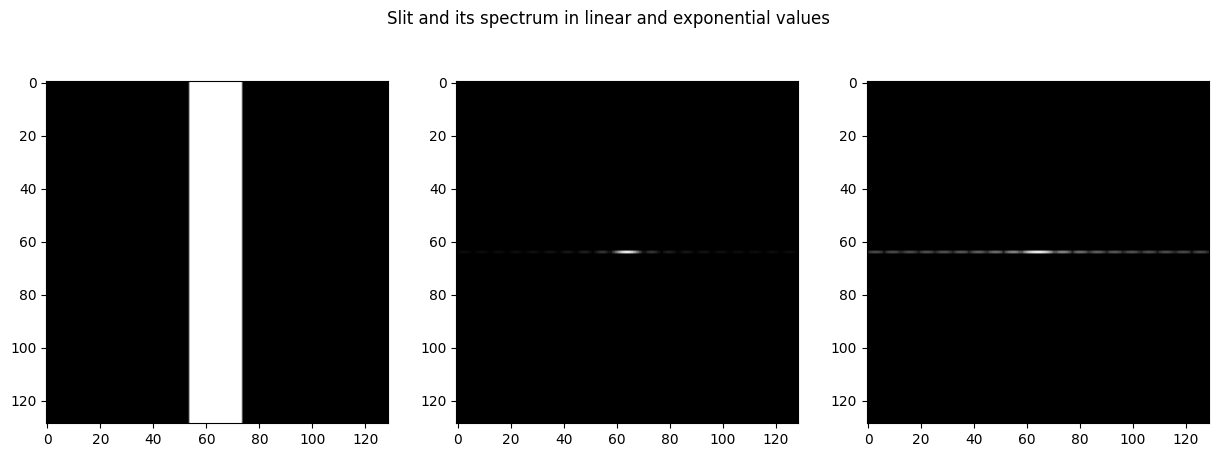

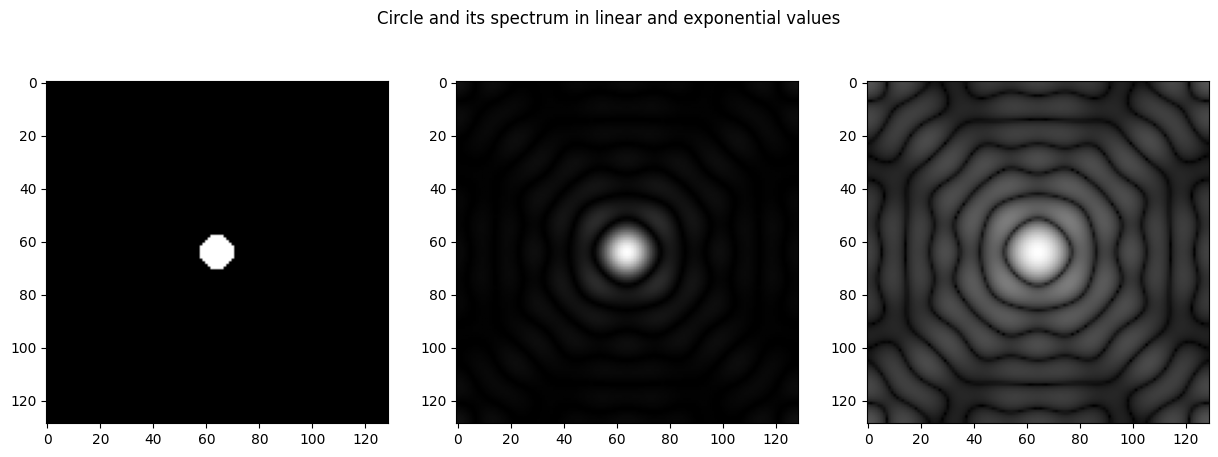

In [ ]:
def get_fft_complex(img):
  fft_img = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(img)))

  return fft_img


def get_fft_real(img):
  fft_img = np.abs(get_fft_complex(img))

  return fft_img


def get_fft_rescaled(img, gamma=0.2):
  # TODO: Get exponentially rescaled values of a fourier transformation provided by get_fft_real
  fft_img = get_fft_real(img) ** (2 * gamma)

  return fft_img

# TODO: Create 128x128 image of a centered vertical slit
slit = np.zeros((129, 129))
c = 129 // 2
w = 10
slit[:, c-w:c+w] = 1

slit_fft_abs = get_fft_real(slit)
slit_fft = get_fft_rescaled(slit)

horizontal_subplots_1x3(slit, slit_fft_abs, slit_fft, "Slit and its spectrum in linear and exponential values")

# TODO: Create binary 128x128 image of a centered circle
circle_radius = .1
x = np.linspace(-1, 1, 129)
xv, yv = np.meshgrid(x, x)

circle = xv ** 2 + yv ** 2 < circle_radius ** 2

circle_fft_abs = get_fft_real(circle)
circle_fft = get_fft_rescaled(circle)

horizontal_subplots_1x3(circle, circle_fft_abs, circle_fft, "Circle and its spectrum in linear and exponential values")


### c) Effects of size

**Tasks**:
- Create a binary 1024x1024 px image `circle_2` of a centered circle with the same relative size as `circle`.
- Get a central crop of `circle_2_fft_abs` and `circle_2_fft` using the function `get_center_crop`.
- Get the logarithmic valued fft `circle_2_fft_log`.

**Programming Hints**:
- Useful functions for this exercise are: `get_meshgrid`, `get_center_crop`, [`np.log10`](https://numpy.org/doc/stable/reference/generated/numpy.log10.html)



**Questions**:
- How is the fourier transformation of the high resolution circle different to the one of the low resolution one? How do you explain this?
- How can you make the high resolution circles fft more similar to the low resolution ones?
- Can you still spot numeric artifacts? If so where?

**Answers**:
-

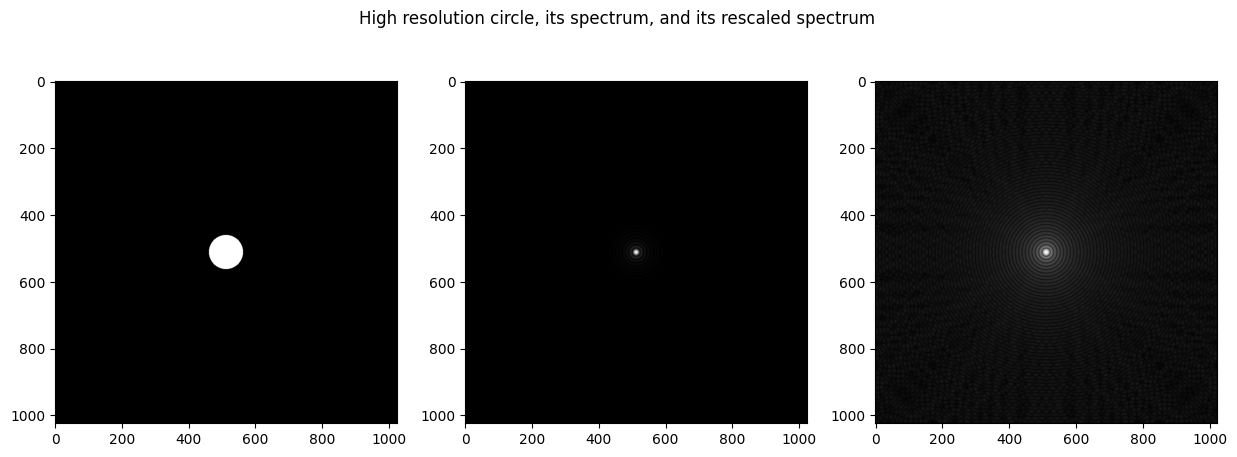

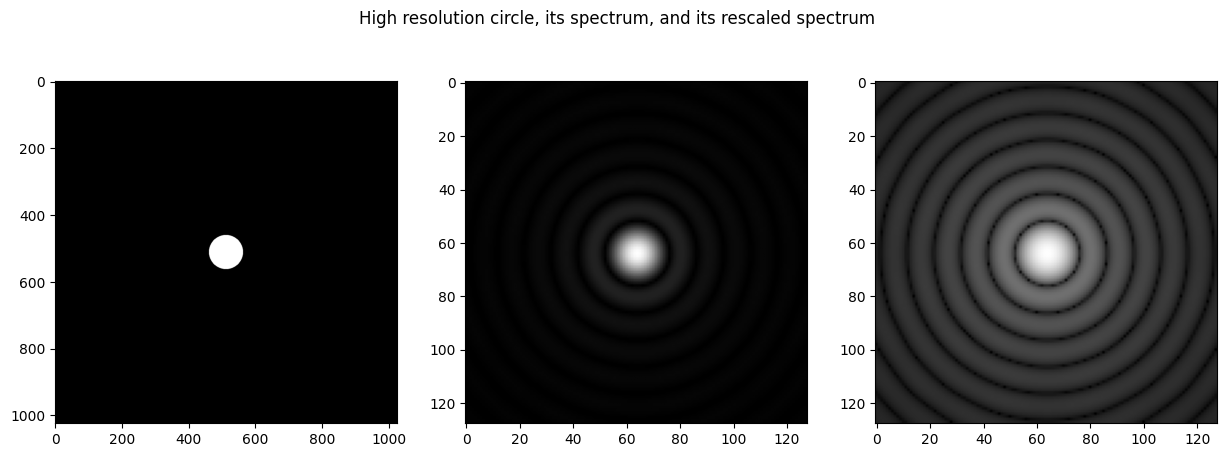

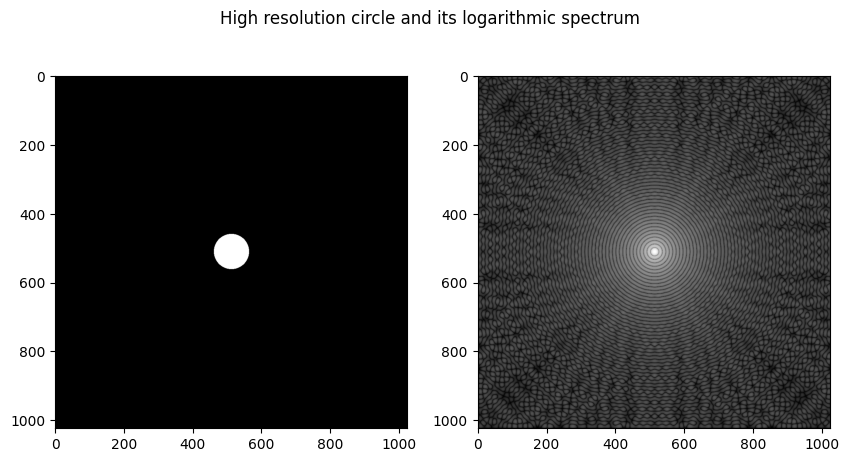

In [ ]:
def get_meshgrid(size_x, size_y):
  x = np.linspace(-1, 1, size_x)
  y = np.linspace(-1, 1, size_y)
  xv, yv = np.meshgrid(x, y)

  return xv, yv


def get_center_crop(img, halfwidth):
  center_row = np.shape(img)[0] // 2
  center_col = np.shape(img)[1] // 2

  center_crop = img[center_row - halfwidth:center_row + halfwidth, center_col - halfwidth:center_col + halfwidth]

  return center_crop


# TODO: Get 1024x1024 image of a centered circle with the same relative circle_radius as for the 128x128 image
xv, yv = get_meshgrid(1024, 1024)
circle_2 = xv ** 2 + yv ** 2 < circle_radius ** 2

circle_2_fft_abs = get_fft_real(circle_2)
circle_2_fft = get_fft_rescaled(circle_2)

horizontal_subplots_1x3(circle_2, circle_2_fft_abs, circle_2_fft, "High resolution circle, its spectrum, and its rescaled spectrum")

# TODO: Get central crop of circle_2_fft_abs
circle_2_fft_abs_crop = get_center_crop(circle_2_fft_abs, halfwidth=64)

# TODO: Get central crop of circle_2_fft
circle_2_fft_crop = get_center_crop(circle_2_fft, halfwidth=64)

horizontal_subplots_1x3(circle_2, circle_2_fft_abs_crop, circle_2_fft_crop, "High resolution circle, its spectrum, and its rescaled spectrum")

# TODO: Get logarithmic values of circle_2_fft_abs
circle_2_fft_log = np.log10(circle_2_fft_abs + 1)

horizontal_subplots_1x2(circle_2, circle_2_fft_log, "High resolution circle and its logarithmic spectrum")


### d) Impact of movements

**Tasks**:
- Implement function `get_phase` to retrieve the phase of an input array `img`.
- Get a centered gaussian `gauss` and its phase `gauss_phase`.
- Get an offset gaussian `gauss_2` and its phase `gauss_2_phase`.
- Calculate phase-difference between `gauss_phase` and `gauss_2_phase`.

**Programming Hints**:
- The phase is the angle of the complex values of the fft.
- Gaussian: $e^{-(x^2 + y^2) / µ}$. $µ = 0.001$ is a good choice.
- Useful functions for this exercise are: [`np.angle`](https://numpy.org/doc/stable/reference/generated/numpy.angle.html), `get_fft_complex`, `get_meshgrid`, [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), and `get_phase`

**Questions**:
- What do you observe in the spectrum when moving the circle?
- What do you observe in the phase when moving the circle or changing the size?
- What do you observe in the spectral difference and phase difference?

**Answers**:
-

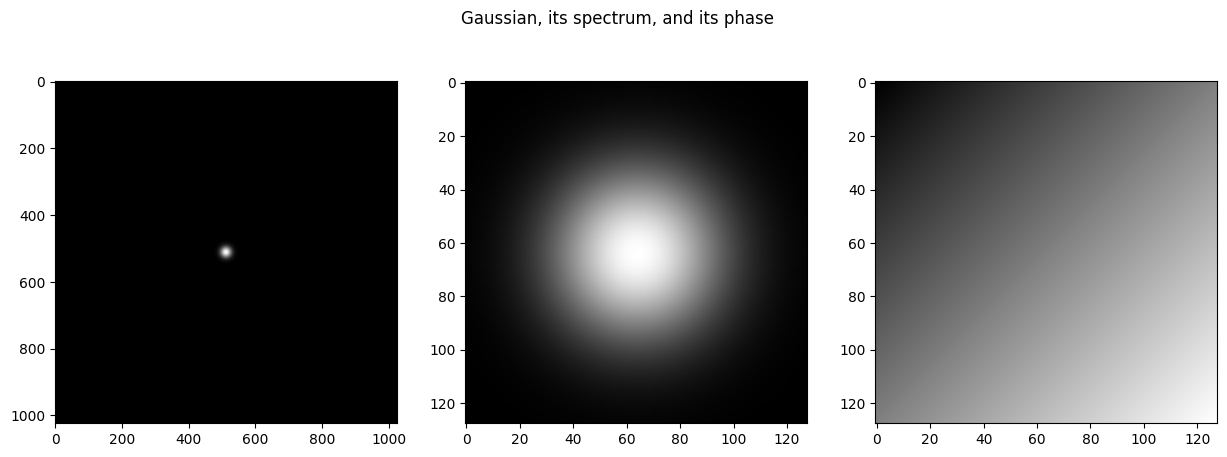

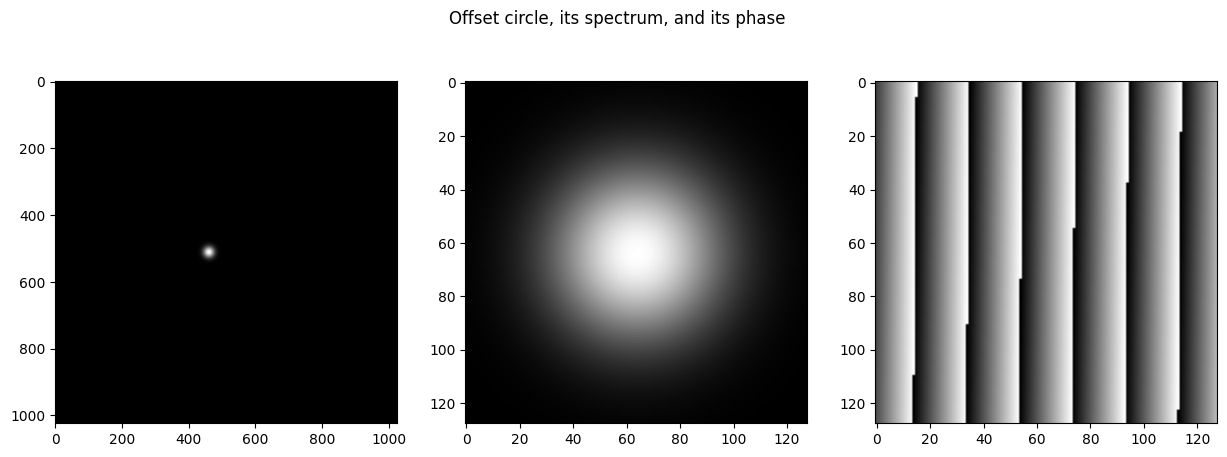

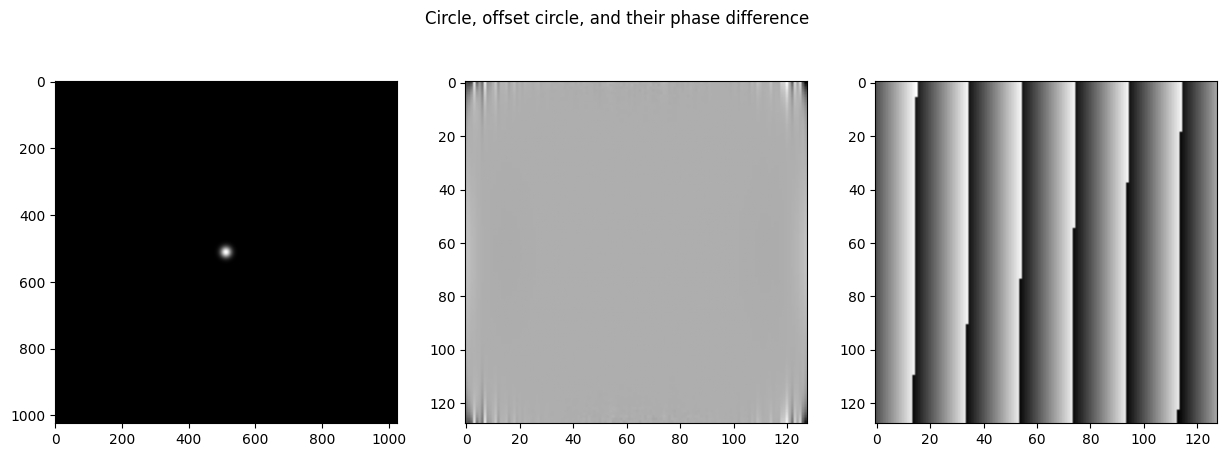

In [ ]:
def get_phase(img):
  # TODO: Implement phase retrievel from input array img
  phase = np.angle(get_fft_complex(img))

  return phase

# TODO: Get centered gaussian on a 1024x1024 image
xv, yv = get_meshgrid(1024, 1024)
gauss = np.exp(-(xv ** 2 + yv ** 2) / 0.001)

gauss_fft = get_fft_rescaled(gauss)

# TODO: Get phase of gauss
gauss_phase = get_phase(gauss)

horizontal_subplots_1x3(gauss, get_center_crop(gauss_fft, 64), get_center_crop(gauss_phase, 64), "Gaussian, its spectrum, and its phase")

# TODO: Get offset gaussian on a 1024x1024 image
xv, yv = get_meshgrid(1024, 1024)
gauss_2 = np.exp(-((xv + 0.1) ** 2 + yv ** 2) / 0.001)

gauss_2_fft = get_fft_rescaled(gauss_2)

# TODO: Get phase of gauss_2
gauss_2_phase = get_phase(gauss_2)

horizontal_subplots_1x3(gauss_2, get_center_crop(gauss_2_fft, 64), get_center_crop(gauss_2_phase, 64), "Offset circle, its spectrum, and its phase")

# TODO: Get fft difference of the gaussians
fft_diff = gauss_2_fft - gauss_fft

# TODO: Get phase difference of the gaussians
phase_diff = gauss_2_phase - gauss_phase

horizontal_subplots_1x3(gauss, get_center_crop(fft_diff, 64), get_center_crop(phase_diff, 64), "Circle, offset circle, and their phase difference")


## Exercise 2: Multiple objects
---

### a) Effects of distance, rotations and size

**Tasks**:
- Get an image `circles_2`, combining the centered circle `circle_2` with another circle of different position.
- Get an image `circles_3`, combining the centered circle `circle_2` with two other circle of different position.
- Get an image `circles_4`, combining four circles positioned like the four on a dice.

**Programming Hints**:
- Useful functions for this exercise are: `get_circle`

**Questions**:
- What do you observe in the spectrum when moving the 2nd circle closer or further away?
- What do you observe in the spectrum when rotating the position of the 2nd circle?
- What do you observe in the spectrum when changing the size of the 2nd circle?
- What do you observe for the three circles? What happens in symmetrical positions?
- What do you observe for four circles in symmetrical positions (like the four on a dice)? What happens when you vary the distance between pairs of circles?

**Answers**:
-

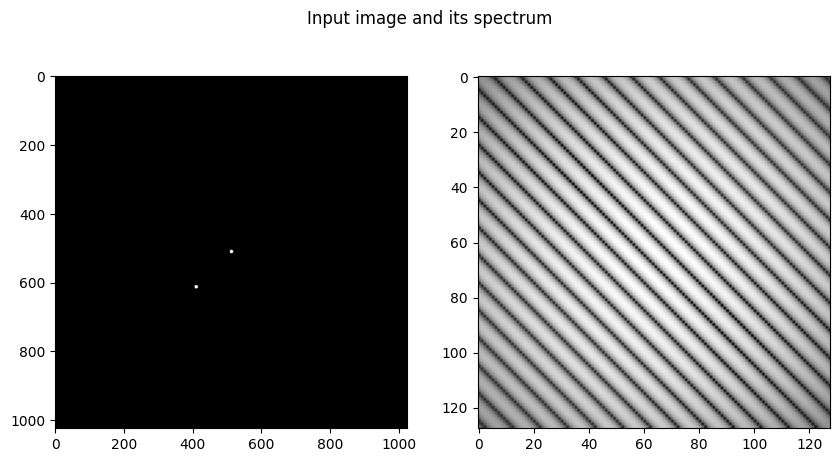

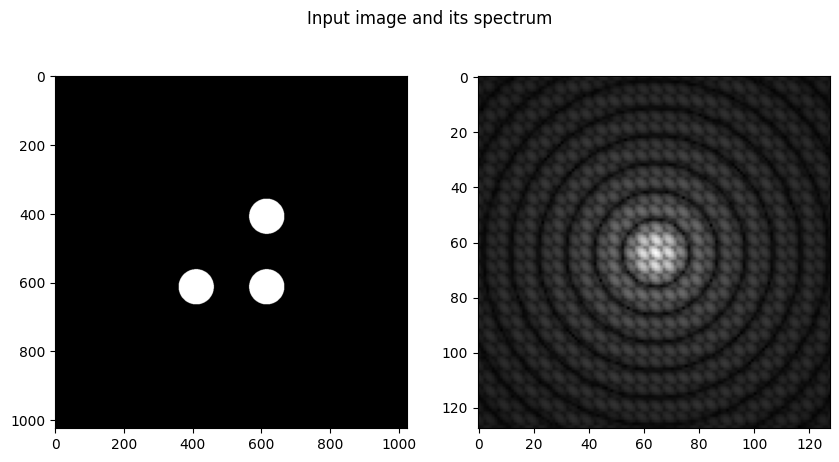

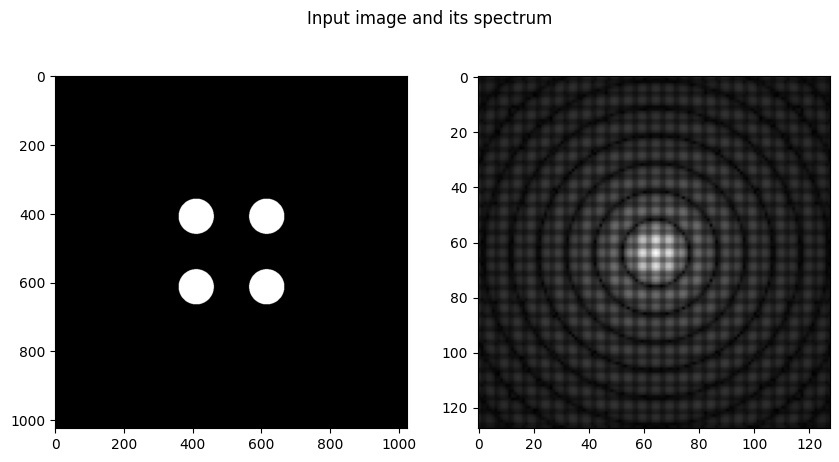

In [ ]:
def get_circle(size_x, size_y, radius, offset_x=0.0, offset_y=0.0):
  xv, yv = get_meshgrid(size_x, size_y)

  circle = ((xv + offset_x) ** 2 + (yv + offset_y) ** 2) < (radius ** 2)

  return circle


# TODO: Get an image combining a central circle (circle_2) and another offset circle
circles_2 = get_circle(1024, 1024, 0.01) + get_circle(1024, 1024, 0.01, 0.2, -0.2)

circles_2_fft = get_center_crop(get_fft_rescaled(circles_2), 64)
horizontal_subplots_1x2(circles_2, circles_2_fft, "Input image and its spectrum")

# TODO: Get an image combining a central circle (circle_2) and two other offset circles
circles_3 = get_circle(1024, 1024, 0.1, -0.2, -0.2) + get_circle(1024, 1024, 0.1, -0.2, 0.2) + get_circle(1024, 1024, 0.1, 0.2, -0.2)

circles_3_fft = get_center_crop(get_fft_rescaled(circles_3), 64)
horizontal_subplots_1x2(circles_3, circles_3_fft, "Input image and its spectrum")

# TODO: Get an image combining four circles, positioned like the four on a dice
circles_4 = (
    get_circle(1024, 1024, 0.1, -0.2, -0.2)
    + get_circle(1024, 1024, 0.1, 0.2, -0.2)
    + get_circle(1024, 1024, 0.1, -0.2, 0.2)
    + get_circle(1024, 1024, 0.1, 0.2, 0.2)
)

circles_4_fft = get_center_crop(get_fft_rescaled(circles_4), 64)
horizontal_subplots_1x2(circles_4, circles_4_fft, "Input image and its spectrum")


### b) Effects of numerous symmetrical objects

**Tasks**:
- Load the images `circ-16.png`  and `circ-32.png` and assign them to `circles_16` and `circles_32` respectively.
- Compute the ffts of `circles_16` and `circles_32`, `circles_16_fft` and `circles_32_fft`, and find a suitable center crop.
- Get an evenly spaced out grid with circles `circle_grid`.

**Programming Hints**:
- Useful functions for this exercise are: [`iio.imread`](https://imageio.readthedocs.io/en/stable/_autosummary/imageio.v3.imread.html), `get_center_crop`, `get_fft_rescaled`, [`range`](https://docs.python.org/3/library/functions.html#func-range), and `get_circle`
- Do note, that the stop number for `range` is **not** included in the range!

**Questions**:
- Can you infer from the spectra how many circles are in the input image? If so, how?
- How can you explain the spectrum resulting from the gridded circles?

**Answers**:
-

0.0878682799774946


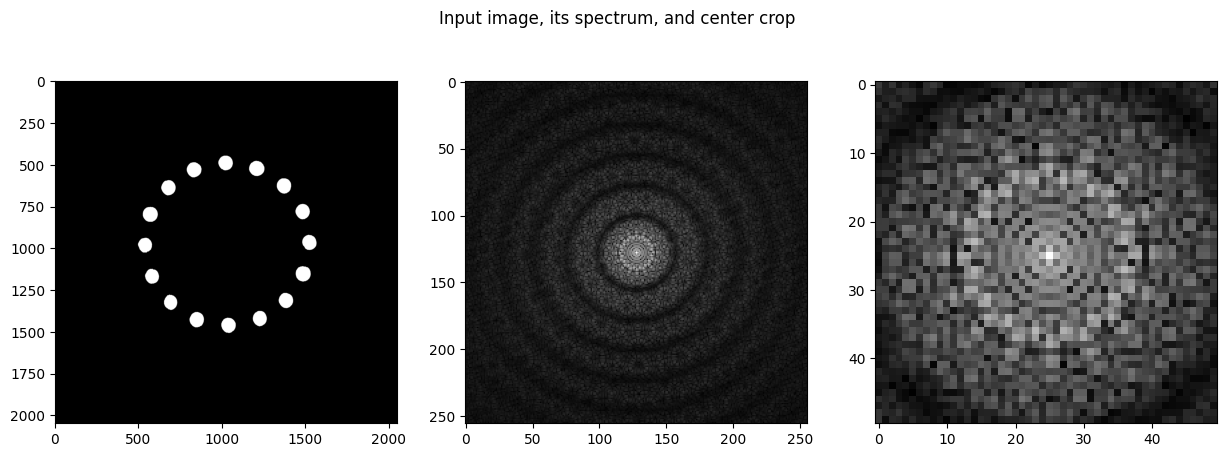

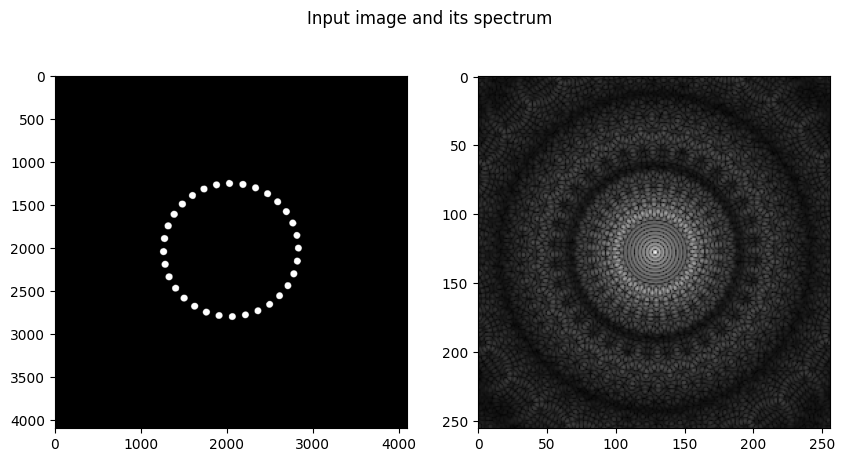

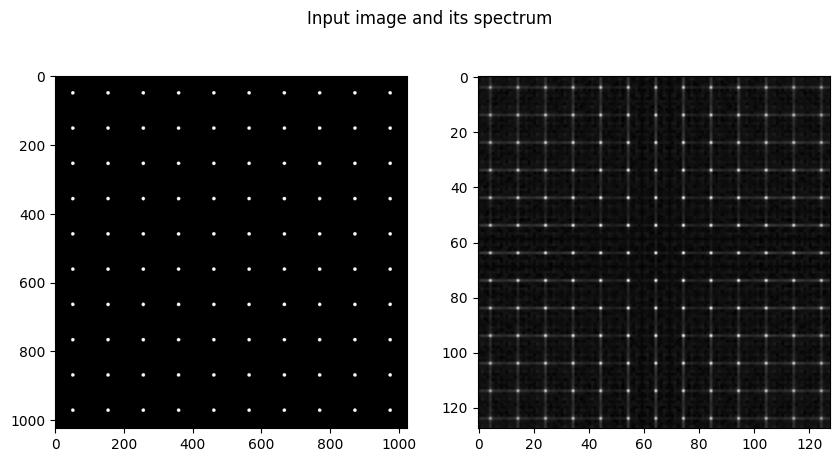

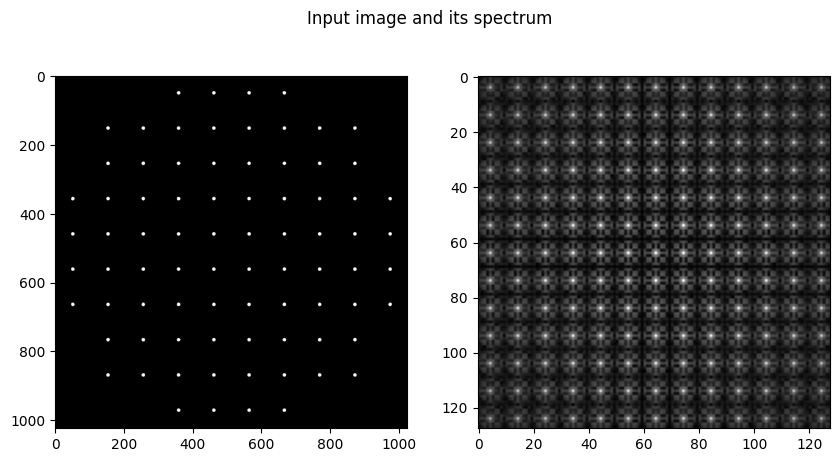

In [ ]:
# TODO: Load image circ-16.png
circles_16 = iio.imread("circ-16.png")

# TODO: Get suitable center crop of rescaled fft of circles_16
crop_size = 128
sum_all = np.sum(get_fft_real(circles_16))
center_crop = get_center_crop(get_fft_rescaled(circles_16), 25)
sum_center = np.sum(get_center_crop(get_fft_real(circles_16), 25))
print(sum_center / sum_all)
circles16_f_fft = get_center_crop(get_fft_rescaled(circles_16), crop_size)

horizontal_subplots_1x3(circles_16, circles16_f_fft, center_crop, "Input image, its spectrum, and center crop")

# TODO: Load image circ-32.png
circles_32 = iio.imread("circ-32.png")

# TODO: Get suitable center crop of rescaled fft of circles_32
circles_32_fft = get_center_crop(get_fft_rescaled(circles_32), crop_size)

horizontal_subplots_1x2(circles_32, circles_32_fft, "Input image and its spectrum")

circle_grid = np.zeros((1024, 1024))
# TODO: Get a grid of evenly spaced out circles
for x_idx in range(-90, 91, 20):
  for y_idx in range(-90, 91, 20):
    circle_grid += get_circle(np.shape(circle_grid)[1], np.shape(circle_grid)[0], 0.01, offset_x=x_idx / 100, offset_y=y_idx / 100)


circle_grid_fft = get_center_crop(get_fft_rescaled(circle_grid), 64)
horizontal_subplots_1x2(circle_grid, circle_grid_fft, "Input image and its spectrum")

circle_grid *= get_circle(1024, 1024, 1)

circle_grid_fft = get_center_crop(get_fft_rescaled(circle_grid), 64)
horizontal_subplots_1x2(circle_grid, circle_grid_fft, "Input image and its spectrum")


### c) Random objects and random objects with symmetries

**Tasks**:
- Get a `nr_samples` randomly distributed circles ,of size `0.05`, in `rng_circles`. Ensure that circles don't overlap the image borders and that circles overlapping each other don't increase the intensity above 1.
- Get an image `rng_circles_sym` by combining `rng_circles` with a shifted copy of itself, thus creating symmetries in the random pattern.

**Programming Hints**:
- Useful functions for this exercise are: [`random.uniform`](https://docs.python.org/3/library/random.html#random.uniform), `get_circle`, and [`np.roll`](https://numpy.org/doc/stable/reference/generated/numpy.roll.html)

**Questions**:
- What do you see in the spectrum of the random distribution of circles?
- What do you see in the spectrum of the random distribution with symmetry?

**Answers**:
-

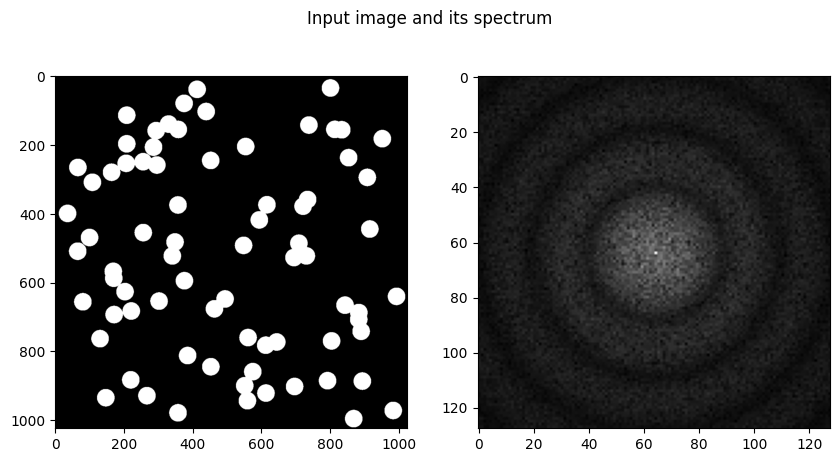

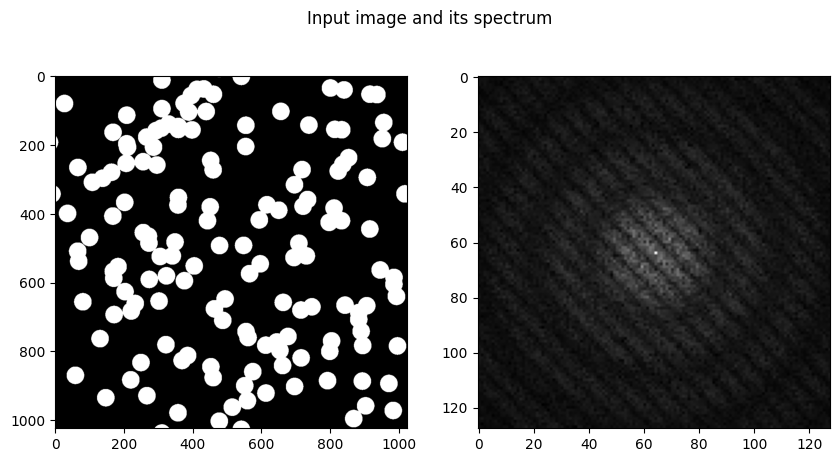

In [ ]:
nr_samples = 75

rng_circles = np.zeros((1024, 1024))

# TODO: Get a randomly distributed circles of size 0.05 that do not overlap image boundaries

for i in range(nr_samples):
  x_idx = random.uniform(-0.95, 0.95)
  y_idx = random.uniform(-0.95, 0.95)
  rng_circles += get_circle(1024, 1024, 0.05, x_idx, y_idx)

# TODO: Ensure overlapping circles don't increase the intensity above 1
rng_circles[rng_circles > 1] = 1

rng_circles_fft = get_center_crop(get_fft_rescaled(rng_circles), 64)
horizontal_subplots_1x2(rng_circles, rng_circles_fft, "Input image and its spectrum")

x_fixed_offset = 0.1 * np.shape(rng_circles)[1]
y_fixed_offset= -0.1 * np.shape(rng_circles)[0]

# TODO: Get symmetry within the random distribution adding it to a shift of itself
rng_circles_sym = np.roll(rng_circles, (int(y_fixed_offset), int(x_fixed_offset)), axis=(0,1)) + rng_circles

# TODO: Ensure overlapping circles don't increase the intensity above 1
rng_circles_sym[rng_circles_sym > 1] = 1


rng_circles_sym_fft = get_center_crop(get_fft_rescaled(rng_circles_sym), 64)
horizontal_subplots_1x2(rng_circles_sym, rng_circles_sym_fft, "Input image and its spectrum")


## Exercise 3: Filtering in fourier space
---

### a) Low- & highpass filtering on simple object and photo

**Tasks**:
- Implement the function `get_lp_hp_filter` to return a fourier space low pass filter kernel `lp_filter`, which removes all signals outside of a centered circle with a given `radius`, and a high pass filter kernel `hp_filter` based on `lp_filter`, which does the opposite.
- Implement the function `filter_fft` to apply a given kernel to an fft.
- Get a 128x128 grating `grating` using your function `get_grating`.

**Programming Hints**:
- Useful functions for this exercise are: `get_circle`, [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html), [`np.fft.ifft2`](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft2.html#), and [`np.fft.ifftshift`](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifftshift.html#)

**Questions**:
- What do you observe for different values of `filter_radius`, e.g. 10 % and 100 %?

**Answers**:
-

In [ ]:
def get_ifft_complex(img):
  img = np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(img)))

  return img


def get_ifft_real(img):
  img = np.abs(get_ifft_complex(img))

  return img


def get_lp_hp_filter(img, radius):
  # TODO: Implement low pass filter
  lp_filter = None

  # TODO: Implement high pass filter
  hp_filter = None

  return [lp_filter, hp_filter]


def filter_fft(fft_img, filter, gamma=0.2):
  # TODO: Apply filter
  fft_img_filtered = None

  # TODO: Get image from spectral data
  img_filtered_complex = None

  fft_img_filtered_rescaled = get_fft_rescaled(img_filtered_complex, gamma)
  img_filtered_abs = np.abs(img_filtered_complex)

  return fft_img_filtered_rescaled, img_filtered_complex, img_filtered_abs


def get_grating(size_x, size_y, hw, sep):
  grating = np.zeros((size_y, size_x))
  spacing = 2 * (hw + sep)

  for i in range(np.shape(grating)[1] // 2, np.shape(grating)[1] + hw, spacing):
    if (i + hw) < np.shape(grating)[1]:
      grating[:, i - hw:i + hw] = 1
    else:
      grating[:, i - hw:np.shape(grating)[1]] = 1

  grating[:, :np.shape(grating)[1] // 2] = grating[:, np.shape(grating)[1]:np.shape(grating)[1] // 2 - 1: -1]

  return grating


# TODO: Set filter_radius
filter_radius = 0.2

halfwidth = 3
grating_separation = 5

# TODO: Get 128x128 grating
grating = None

camera_img = iio.imread("cameraman.tif")

for image in [grating, camera_img]:
  image_fft = get_fft_complex(image)
  horizontal_subplots_1x2(image, get_fft_rescaled(image, gamma=0.1), "Image and its spectrum")

  lp_hp_filter = get_lp_hp_filter(image_fft, filter_radius)
  for filter in lp_hp_filter:
    image_fft_filtered, _, image_filtered = filter_fft(image_fft, filter, gamma=0.1)
    horizontal_subplots_1x2(image_fft_filtered, image_filtered, "Filtered spectrum and image")


### b) 1D Filtering on 2D object

**Tasks**:
- Implement the function `get_vert_horiz_filter` to return a fourier space filter kernel `vert_filter`, which removes all frequencies except those horizontal ones on the vertical zero frequency, and a filter kernel `horiz_filter` based on `vert_filter`, which does the same in the opposite direction.
- Get a 128x128 2D grating based on `get_grating`.

**Programming Hints**:
- Useful functions for this exercise are: [`np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html), [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html), [`np.transpose`](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html), and `get_grating`

**Questions**:
- What do you observe for the different filtering directions?

**Answers**:
-

In [ ]:
def get_vert_horiz_filter(img):
  # TODO: Get a filter to remove all frequencies except those horizontal ones on the vertical 0 frequency
  vert_filter = None

  # TODO: Get a filter, based on vert_filter, to remove all frequencies except those vertical ones on the horizontal 0 frequency
  horiz_filter = None

  return [vert_filter, horiz_filter]


halfwidth = 3
grating_separation = 5

# TODO: Get a 2D grating based on your get_grating function
grating_1D = get_grating(128, 128, halfwidth, grating_separation)
grating_2d = None

grating_2d_fft = get_fft_complex(grating_2d)
horizontal_subplots_1x2(grating_2d, get_fft_rescaled(grating_2d), "Image and its spectrum")

v_h_filter = get_vert_horiz_filter(grating_2d)
for filter in v_h_filter:
  grating_2d_fft_filtered, _, grating_filtered = filter_fft(grating_2d_fft, filter)
  horizontal_subplots_1x2(grating_2d_fft_filtered, grating_filtered, "Filtered spectrum and image")


### c) 1D Filtering comparison of x-y-grating and array of squares

**Tasks**:
- Get an array of squares `squares` using your previous `grating_2d`.

**Programming Hints**:
- Useful functions for this exercise are: [`np.abs`](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html)

**Questions**:
- How are the spectrum of the `grating_2d`and the `squares` different? Why is that?
- What do you observe for the different filtering directions? How is it compared to the `grating_2d`

**Answers**:
-

In [ ]:
# TODO: Invert your grating_2d to get an array of squares
squares = None

# TODO: Get absolute valued difference of the rescaled ffts of squares and the 2d grating
fft_diff = None

squares_fft = get_fft_complex(squares)
horizontal_subplots_1x3(squares, get_fft_rescaled(squares), fft_diff, "Image, its spectrum, and the spectral difference with the 2d grating")

v_h_filter = get_vert_horiz_filter(grating_2d)
for filter in v_h_filter:
  squares_fft_filtered, _, grating_filtered = filter_fft(squares_fft, filter)
  horizontal_subplots_1x2(squares_fft_filtered, grating_filtered, "Filtered spectrum and image")

### d) Rasterized printed image

**Tasks**:
- Get a lowpass filter offset from the center.

**Programming Hints**:
- Useful functions for this exercise are: `get_circle` and [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html)

**Questions**:
- What do you observe in the spectrum of the image?
- What do you observe when filtering only a single offset dirac-peak with its surroundings?

**Answers**:
-

In [ ]:
# Our image to work with
mask_img = iio.imread("mask.png")

mask_img_fft = get_fft_complex(mask_img)
mask_img_fft_real = get_fft_rescaled(mask_img, gamma=0.01)
horizontal_subplots_1x3(mask_img, mask_img_fft_real, get_center_crop(mask_img_fft_real, 256), "Image, its spectrum, and a magnification")

# TODO: Get an offset lowpass filter
filter_radius = 0.05
x_offset = None
y_offset = None
offset_filter = get_circle(np.shape(mask_img)[1], np.shape(mask_img)[0], filter_radius, x_offset, y_offset)

mask_img_fft_filtered, _, mask_img_filtered = filter_fft(mask_img_fft, offset_filter, gamma=0.1)
horizontal_subplots_1x3(get_center_crop(mask_img_fft_filtered, 256), mask_img_filtered, get_center_crop(mask_img_fft_real * (1 - offset_filter), 256), "Filtered spectrum, filtered image, and surrounding of filter")

## Exercise 4: Phase images
---

### a) Real image with random phase

**Tasks**:
- Get a complex image `camera_img_complex` by assigning each pixel of `camera_img` a random phase value out of a uniform distribution.

**Programming Hints**:
- $cos(α) + i * sin(α) = exp(i * α)$
- Useful functions for this exercise are: [`np.random.rand`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html), [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html), and [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)
- Useful constants are: [`np.pi`](https://numpy.org/doc/stable/reference/constants.html#numpy.pi) as π and `1j` as imaginary unit

**Questions**:
- What do you observe in the spectrum of the complex image? How does it compare to the real valued on?
- What do you observe regarding the effects of the filters?

**Answers**:
-

In [ ]:
def get_random_phases(img):
  # TODO: Get random uniformely distributed phase values
  phase = None

  return phase


camera_img_complex = copy.copy(camera_img)
phase = get_random_phases(camera_img_complex)

# TODO: Transform real image to complex image with random phase values
camera_img_complex = None

horizontal_subplots_1x2(np.abs(camera_img_complex), get_fft_rescaled(camera_img_complex), "Complex image and its spectrum")
camera_img_complex_fft = get_fft_complex(camera_img_complex)

# TODO: Set filter_radius
filter_radius = 0.1

lp_hp_filter = get_lp_hp_filter(camera_img_complex_fft, filter_radius)
for filter in lp_hp_filter:
  camera_img_fft_filtered, _, camera_img_filtered = filter_fft(camera_img_complex_fft, filter, gamma=0.1)
  horizontal_subplots_1x2(camera_img_fft_filtered, camera_img_filtered, "Filtered spectrum and image")

### b) Low- & highpass on phase image

**Tasks**:
- Implement the function `rescale_0_1` to rescale the values of an array `img` to $[0, 1]$.
- Convert `phase_img` into a pure phase image with small amplitudes according to:

$$
\begin{align}
    phase\_img = exp(i*0.1*π*scaled\_img)
\end{align}
$$

- Get the phase of the filtered image `phase_img_filtered_complex`.

**Programming Hints**:
- Useful functions for this exercise are: [`np.amin`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html#), [`np.amax`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html), [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), and [`np.angle`](https://numpy.org/doc/stable/reference/generated/numpy.angle.html)
- Useful constants are: [`np.pi`](https://numpy.org/doc/stable/reference/constants.html#numpy.pi) as π and `1j` as imaginary unit

**Questions**:
- What do you observe for the phase image `phase_img` and spectrum compared to the real valued `img` from previously?
- What do you observe regarding the effects of the filters and what do you observe when displaying the angle of the filtered image `filtered_img`?

**Answers**:
-

In [ ]:
def rescale_0_1(img):
  # TODO: Scale to [0, 1]
  img = None

  return img

phase_img = copy.copy(camera_img)

# TODO: Convert to phase image
phase_img = None

phase_img_fft_real = get_fft_rescaled(phase_img, gamma=0.01)
phase_img_fft = get_fft_complex(phase_img)
# Rounding due to numerical errors.
horizontal_subplots_1x2(np.around(np.abs(phase_img), 5), phase_img_fft_real, "Phase image and its spectrum")

# TODO: Set filter_radius
filter_radius = 0.01

lp_hp_filter = get_lp_hp_filter(phase_img_fft, filter_radius)
for filter in lp_hp_filter:
  phase_img_fft_filtered, phase_img_filtered_complex, phase_img_filtered = filter_fft(phase_img_fft, filter, gamma=0.1)

  # TODO: Get the angle of the phase_img_filtered_complex
  phase_img_filtered_angle = None

  horizontal_subplots_1x3(phase_img_fft_filtered, phase_img_filtered_angle, phase_img_filtered, "Filtered spectrum, angle of spectrum, and image")


### c) Knife edge on phase image

**Tasks**:
- Get knife edge filters for the 4 main directions.

**Programming Hints**:
- The arrays `xv` and `yv` don't have to be combined.

**Questions**:
- What do you observe when applying the filter in different axis directions?
- What do you observe when applying the filter to the positive side of an axis vs to the negative side?

**Answers**:
-

In [ ]:
xv, yv = get_meshgrid(np.shape(phase_img)[1], np.shape(phase_img)[0])

# TODO: Implement X-axis knife edge, removing the negative axis part
x_neg_filter = None

# TODO: Implement X-axis knife edge, removing the positive axis part
x_pos_filter = None

# TODO: Implement Y-axis knife edge, removing the negative axis part
y_neg_filter = None

# TODO: Implement Y-axis knife edge, removing the positive axis part
y_pos_filter = None

horizontal_subplots_1x2(x_neg_filter, x_pos_filter, "Knife edge filter for X-axis")
horizontal_subplots_1x2(y_neg_filter, y_pos_filter, "Knife edge filter for Y-axis")

knife_edge_filter = [x_neg_filter, x_pos_filter, y_neg_filter, y_pos_filter]
for filter in knife_edge_filter:
  display_filtered_fft_img, _, display_filtered_img = filter_fft(phase_img_fft, filter, gamma=0.1)
  horizontal_subplots_1x2(display_filtered_fft_img, display_filtered_img, "Filtered spectrum and image")

### d) Phase shifting the DC part on phase image

**Tasks**:
- Apply a phase shift to only the DC part of the spectrum.

**Programming Hints**:
- The zero frequency lies at 0,0 when not fftshifted.
- Phase: $cos(α) + i * sin(α) = exp(i * α)$
- Useful functions for this exercise are: [`np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html), [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html), [`np.fft.fftshift`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftshift.html#), and [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html).
- Useful constants are: [`np.pi`](https://numpy.org/doc/stable/reference/constants.html#numpy.pi) as π and `1j` as imaginary unit

**Questions**:
- What happens for different phase shift values?

**Answers**:
-

In [ ]:
# TODO: Set phase shift
phase_shift = None

# TODO: Create mask with only zeros and set the 0 frequencies position to 1
dc_mask = None

# TODO: Add phase shift to the mask
dc_filter = None

display_filtered_fft_img, _, display_filtered_img = filter_fft(phase_img_fft, dc_filter, gamma=0.01)
horizontal_subplots_1x2(display_filtered_fft_img, display_filtered_img, "Filtered spectrum and image")

### e) Reconstructing an image from fourier space with missing phase information

**Tasks**:
- Implement the Gerchberg-Saxton algorithm. The idea is that only the fourier plane amplitudes are known. Hence, phase information is missing! However, it is also known that the object space has no phases. This can be used by guessing random phases in fourier space and then iteratively refine this guess by continously switching between planes while removing phases in the object space and exchanging amplitudes by the known fourier amplitudes in fourier space (thus, just udating the phases).

**Programming Hints**:
- Useful functions for this exercise are: `get_ifft_real`, [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), and `get_random_phases`

**Questions**:
- Can the object be retrieved without errors like this?

**Answers**:
-

In [ ]:
def get_ifft_real(img):
  img = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(img))))

  return img


def gs_phase_retrival(gs_fft_amp):
  # TODO: Get fourier space estimate by combining gs_fft_amp with random phases
  gs_fft_estimate = None

  # TODO: Get object space estimate by as real valued ifft of gs_fft_estimate to remove phases
  gs_img_estimate = None

  # TODO: Set amount of epochs
  epochs = 1

  entropy = [scipy.stats.entropy(gs_img_estimate, axis=None)]

  for i in range(epochs):
    # TODO: Update gs_fft_estimate by assigning the phases of the fft of gs_img_estimate to the known amplitudes gs_fft_amp
    gs_fft_estimate = None

    # TODO: Update gs_img_estimate by getting the absolute valued ifft of gs_fft_estimate to remove phases again
    gs_img_estimate = None

    entropy.append(scipy.stats.entropy(gs_img_estimate, axis=None))

  return gs_img_estimate, gs_fft_estimate, entropy


gs_img = iio.imread("circ-32-generated.png")
gs_img_fft_real = get_fft_real(gs_img)

# TODO: Get real valued ifft of gs_img_fft_real
gs_img_ifft_real = None

horizontal_subplots_1x3(gs_img, gs_img_fft_real ** 0.2, gs_img_ifft_real ** 0.2, "Input image, its spectrum, and the ifft of the spectrum after removing phase information")

gs_img_estimate, _, entropy = gs_phase_retrival(gs_img_fft_real)

horizontal_subplots_1x2(gs_img, gs_img_estimate, "Input image and its reconstruction")
plt.plot(entropy)
plt.title("Shannon entropy of the object space over epochs")
plt.show()

## Exercise 4: Holographic images
---

### a) Working with holographic data

**Tasks**:
- Implement funciton `lambda_to_k` to convert inputs `lambda_obj` from object- to k-space.
- Set image acquisition variables. It was acquired with the following parameters:
  - Pixel-spacing on the camera: $Δx = Δy = 10 μm$
  - Wavelength: $λ = 600 nm$
  - Distanz of object to camera: $< 1 m$
  - Plane referencewave
- Transform image acquisition variables to k-space.
- Find the part of the spectrum containing the image.

**Programming Hints**:
- $λ = \frac{2π}{k}$
- Useful function are: [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html)
- Useful constants are: [`np.pi`](https://numpy.org/doc/stable/reference/constants.html#numpy.pi) as π

**Questions**:
- Why do we need to convert our acquisition variables to k-space?
- What are the bright areas in the spectrum ?

**Answers**:
-

In [ ]:
# The hologram to work with
holo_img = iio.imread('hologram.png')

holo_fft_img = get_fft_complex(holo_img)
horizontal_subplots_1x2(holo_img, get_fft_rescaled(holo_img, gamma=0.1), "Input image and its spectrum")


def lambda_to_k(lambda_obj):
  # TODO: Lambda to k conversion
  k = None

  return k


# TODO: Set pixel spacing
dx = None
dy = None
dkx = None
dky = None

# TODO: Set wavelength
wl = None
k = None

# TODO: Set maximum object distance
max_dist = 1

### b) Finding the first orders

**Tasks**:
- Cut out the parts of the spectrum containing the first orders of the image

**Programming Hints**:
- To index an area of an array use `example_arr[start_row:end_row, start_col:end_col]`

**Questions**:
- Why do we need to cut out the first orders?

**Answers**:
-

In [ ]:
# TODO: Cut both first order objects from the spectrum
holo_first_order_1 = None
holo_first_order_2 = None

horizontal_subplots_1x2(np.abs(holo_first_order_1) ** 0.2, np.abs(holo_first_order_2) ** 0.2, "First order objects")

### c) Reconstructing holographic data

**Tasks**:
- Implement the function `get_prop_kernel` to get the filter kernel for propagation of the wavefield.

**Programming Hints**:
- Useful function are: [`np.shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html), [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), and [`np.sqrt`](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html)
- Useful constants are: [`np.pi`](https://numpy.org/doc/stable/reference/constants.html#numpy.pi) as π and `1j` as imaginary unit

**Questions**:
- What is the imaged object?
- At which reconstruction distance is the image reconstructed well?
- Which imaging geometry must've been used?
- What is the difference between the two first orders?

**Answers**:
-

In [ ]:
def get_prop_kernel(fft_img, z, k, dkx, dky):
  # TODO: get height and width of the fft_img
  height, width = None

  x = np.linspace(-1, 1, width)
  y = np.linspace(-1, 1, height)

  # TODO: Get kx and ky vectors based on the relative x and y vectors
  kx = None
  ky = None

  kxv, kyv = np.meshgrid(kx, ky)

  # TODO: Get propagation kernel
  prop_kernel = None

  return prop_kernel


step = .25
for z in np.arange(- max_dist, max_dist + step, step):
  z = np.around(z, 2)
  prop_kernel = get_prop_kernel(holo_first_order_1, z, k, dkx, dky)
  display_filtered_fft_img, _, display_filtered_img_1 = filter_fft(holo_first_order_1, prop_kernel)
  __, _, display_filtered_img_2 = filter_fft(holo_first_order_2, prop_kernel)
  horizontal_subplots_1x3(display_filtered_fft_img, display_filtered_img_1, display_filtered_img_2, f"Filtered spectrum and images of the different first orders at {z} m")